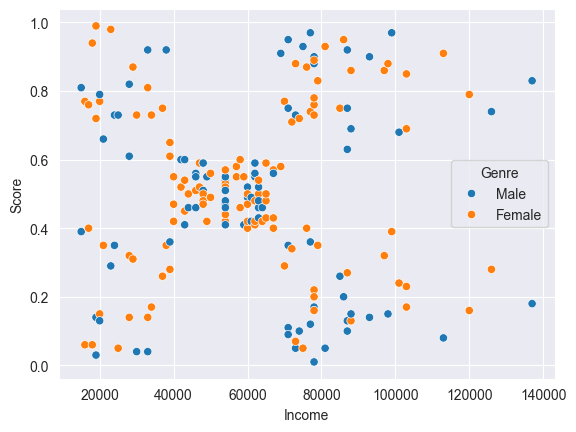

   Age  Income  Score  Genre_Female  Genre_Male
0   19   15000   0.39         False        True
1   21   15000   0.81         False        True
2   20   16000   0.06          True       False
3   23   16000   0.77          True       False
4   31   17000   0.40          True       False


In [49]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML6.1%20clustering/data/mall_customers_clustering.csv", index_col=0)

sns.scatterplot(x='Income', y='Score', hue='Genre', data=df)
plt.show()

x = df.drop(['CustomerID'], axis=1)
X = pd.get_dummies(x)

print(X.head())

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


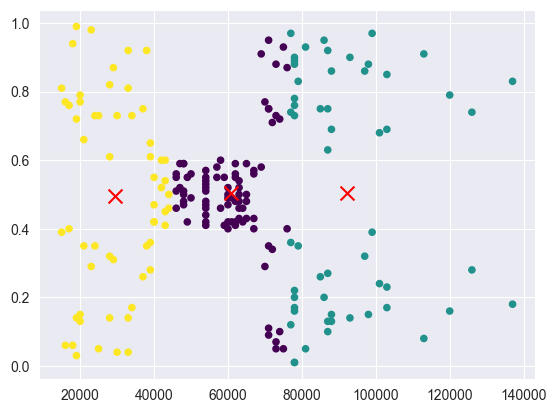

In [50]:
from sklearn.cluster import KMeans

k_means = KMeans(n_clusters=3, random_state=42).fit(X)
y_kmeans = k_means.labels_

print(y_kmeans)

plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], s=100, c='red', marker='x')
plt.show()

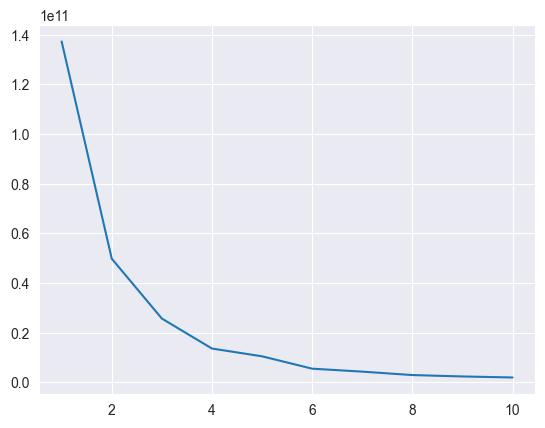

In [51]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42).fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.show()

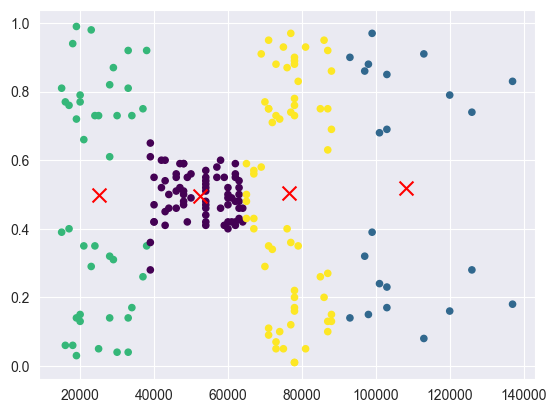

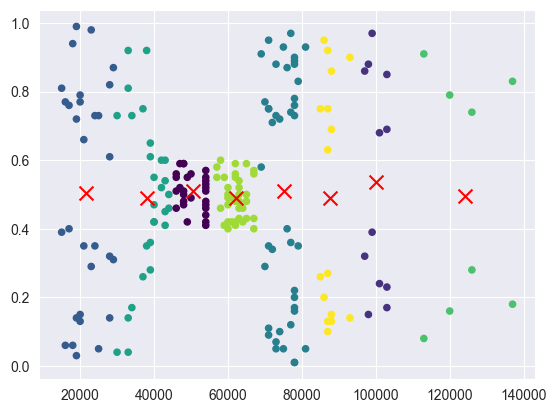

In [52]:
k_means = KMeans(n_clusters=4, random_state=42).fit(X)
y_kmeans = k_means.labels_

plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], s=100, c='red', marker='x')
plt.show()

k_means = KMeans(n_clusters=8, random_state=42).fit(X)
y_kmeans = k_means.labels_

plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], s=100, c='red', marker='x')
plt.show()

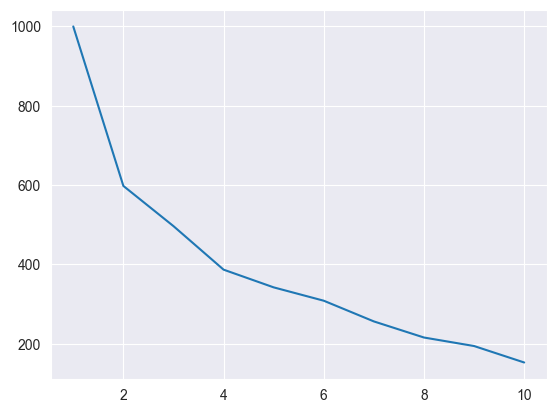

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X)

X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42).fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.show()


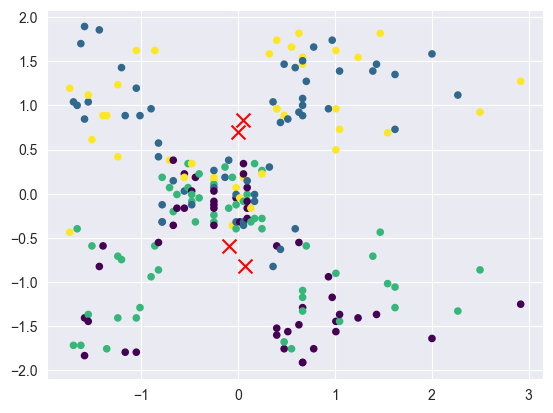

In [54]:
k_means = KMeans(n_clusters=4, random_state=42).fit(X_scaled)
y_kmeans = k_means.labels_

plt.scatter(X_scaled.Income, X_scaled.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], s=100, c='red', marker='x')
plt.show()

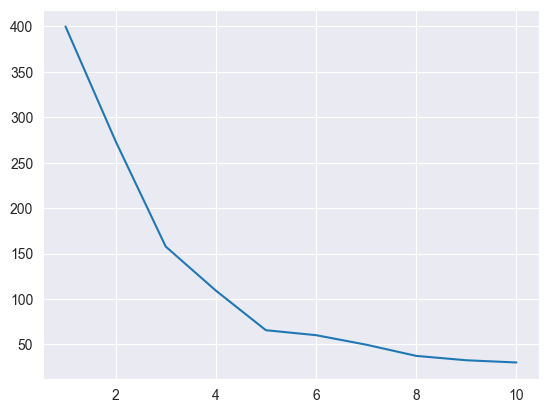

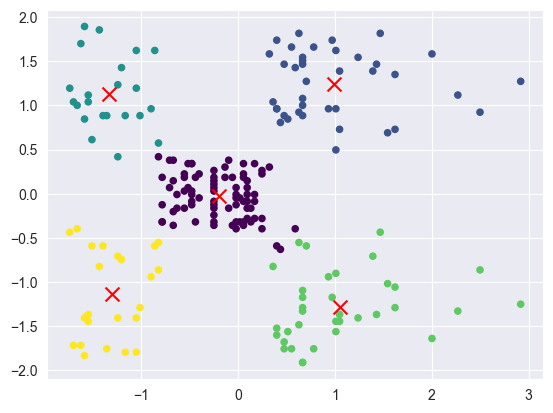

In [55]:
X_flat = X_scaled.drop(['Age', 'Genre_Female', 'Genre_Male'], axis=1)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42).fit(X_flat)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.show()

k_means = KMeans(n_clusters=5, random_state=42).fit(X_flat)
y_kmeans = k_means.labels_

plt.scatter(X_scaled.Income, X_scaled.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], s=100, c='red', marker='x')
plt.show()

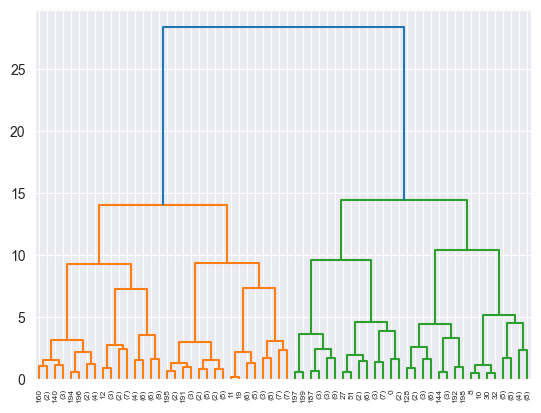

In [56]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model.fit(X_scaled)

def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)

plot_dendrogram(model, truncate_mode="level", p=5)

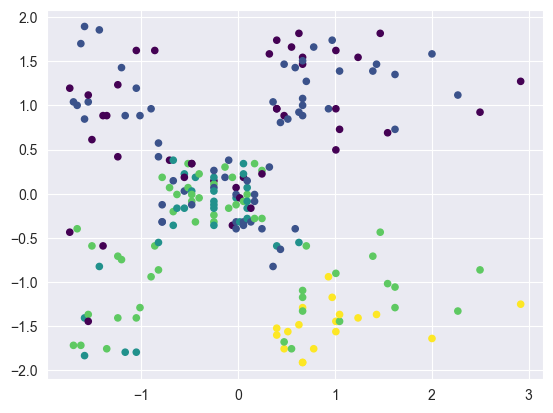

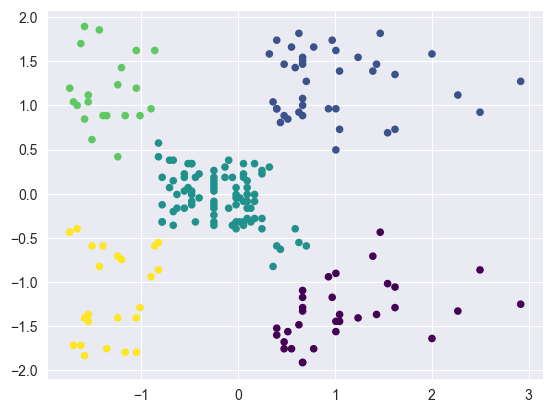

In [57]:
agg_clustering = AgglomerativeClustering(n_clusters=5).fit(X_scaled)
y_agg = agg_clustering.labels_

plt.scatter(X_flat.Income, X_flat.Score, c=y_agg, s=20, cmap='viridis')

plt.show()

agg_clustering = AgglomerativeClustering(n_clusters=5).fit(X_flat)
y_agg = agg_clustering.labels_

plt.scatter(X_flat.Income, X_flat.Score, c=y_agg, s=20, cmap='viridis')
plt.show()

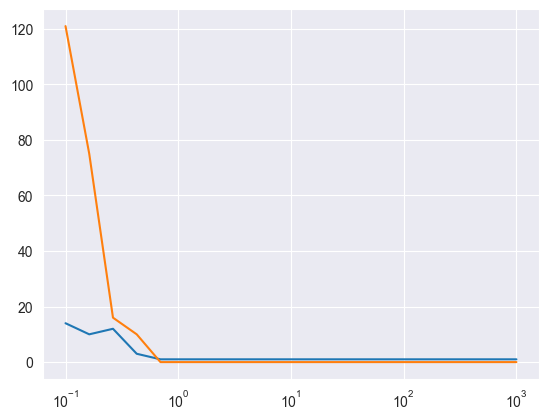

In [58]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.4, min_samples=3).fit(X_flat)
y_db = db.labels_

n_clusters_ = len(set(y_db)) - (1 if -1 in y_db else 0)
n_noise_ = list(y_db).count(-1)

clusters, noise = [], []
for i in np.logspace(-1, 3, 20):
  db = DBSCAN(eps=i, min_samples=3).fit(X_flat)
  y_db = db.labels_

  clusters.append(len(set(y_db)) - (1 if -1 in y_db else 0))
  noise.append(list(y_db).count(-1))

plt.plot(np.logspace(-1, 3, 20),clusters)
plt.plot(np.logspace(-1, 3, 20),noise)
plt.xscale('log')
_ = plt.show()

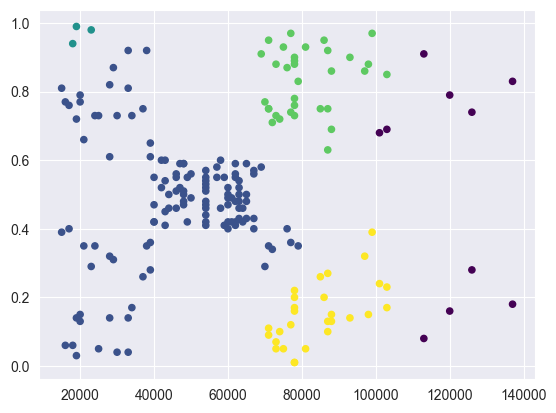

In [59]:
db = DBSCAN(eps=0.4, min_samples=3).fit(X_flat)
y_db = db.labels_

plt.scatter(X.Income, X.Score, c=y_db, s=20, cmap='viridis')

In [60]:
kmeans = KMeans(n_clusters=4, random_state=42).fit(X_scaled)
labels = kmeans.labels_

X_cluster = X.copy()
X_cluster['cluster'] = labels

import numpy as np

centers = kmeans.cluster_centers_

def closest_points(X_scaled, labels, centers, k=5):
    res = {}
    for i, c in enumerate(centers):
        idx = np.where(labels == i)[0]
        dists = np.linalg.norm(X_scaled.iloc[idx] - c, axis=1)
        closest_idx = idx[np.argsort(dists)[:k]]
        res[i] = closest_idx
    return res

closest = closest_points(X_scaled, labels, centers, k=5)

for cl, idxs in closest.items():
    print(f"\nКластер {cl}:")
    print(X.iloc[idxs])


Кластер 0:
     Age  Income  Score  Genre_Female  Genre_Male
98    48   61000   0.42         False        True
126   43   71000   0.35         False        True
146   48   77000   0.36         False        True
107   54   63000   0.46         False        True
85    48   54000   0.46         False        True

Кластер 1:
     Age  Income  Score  Genre_Female  Genre_Male
133   31   72000   0.71          True       False
88    34   58000   0.60          True       False
125   31   70000   0.77          True       False
87    22   57000   0.55          True       False
159   30   78000   0.73          True       False

Кластер 2:
    Age  Income  Score  Genre_Female  Genre_Male
79   49   54000   0.42          True       False
83   46   54000   0.44          True       False
71   47   49000   0.42          True       False
89   50   58000   0.46          True       False
96   47   60000   0.47          True       False

Кластер 3:
     Age  Income  Score  Genre_Female  Genre_Male
137   32

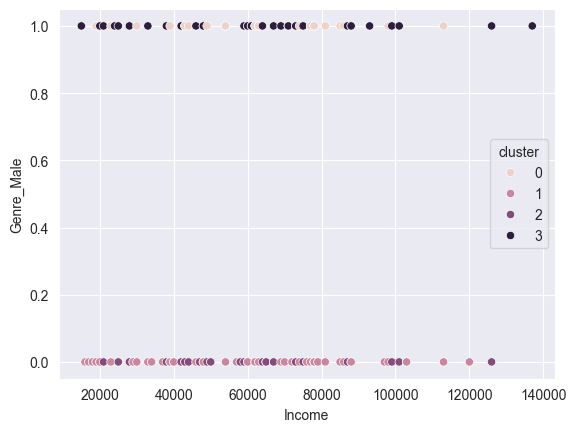

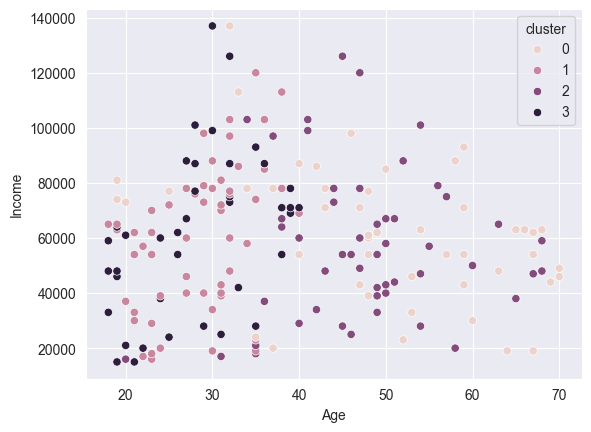

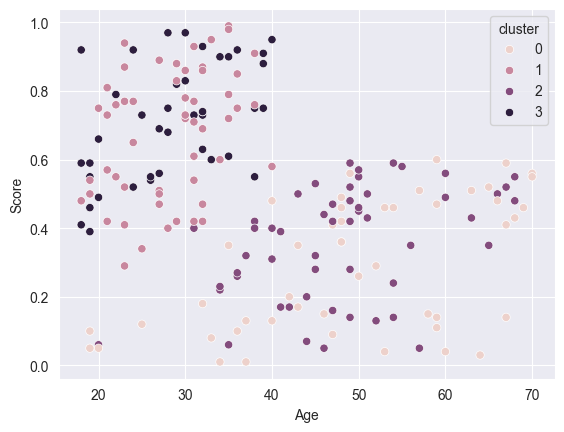

In [61]:
pairs = {
    ('Age', 'Income'),
    ('Age', 'Score'),
    ('Income', 'Genre_Male'),
}

for x, y in pairs:
    sns.scatterplot(data=X_cluster, x=x, y=y, hue='cluster')
    plt.show()

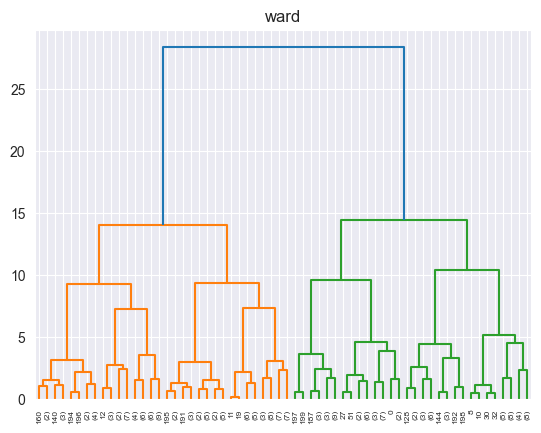

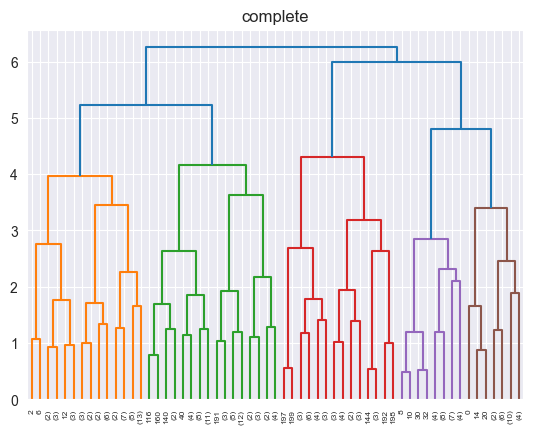

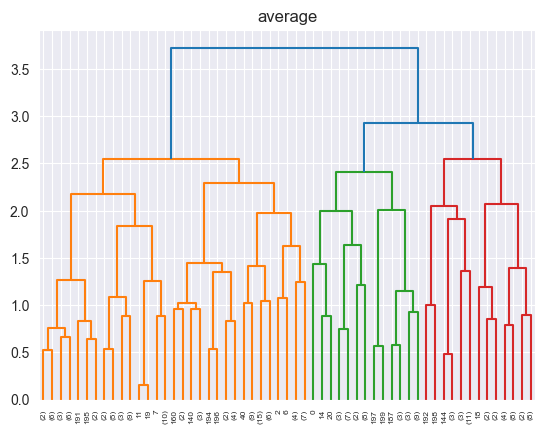

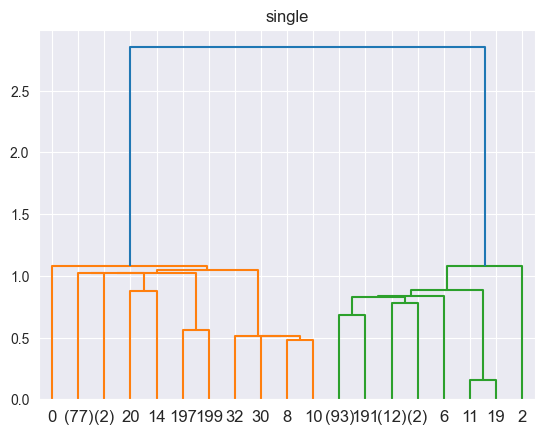

In [62]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

methods = ['ward', 'complete', 'average', 'single']



def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)

for method in methods:
    model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage=method)
    model.fit(X_scaled)
    plot_dendrogram(model, truncate_mode="level", p=5)
    plt.title(method)
    plt.show()

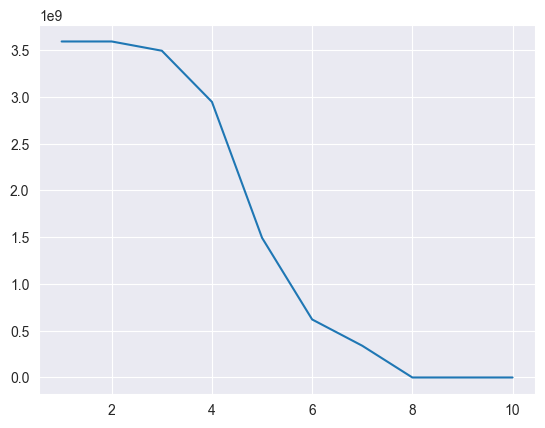

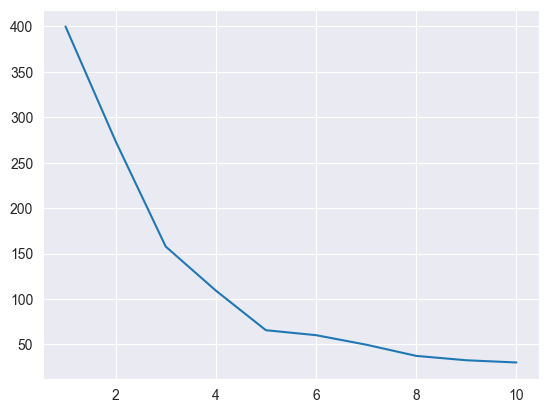

In [63]:
wcss = []
for i in range(1, 11):
    db = DBSCAN(eps=0.4, min_samples=i)
    labels = db.fit_predict(X_scaled)
    m = 0
    for label in set(labels):
        if label == -1:
            continue
        cluster = X[labels == label]
        center = cluster.mean(axis=0)
        m += np.sum((cluster - center) ** 2)
    wcss.append(m)
plt.plot(range(1, 11), wcss)
plt.show()

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42).fit(X_flat)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.show()

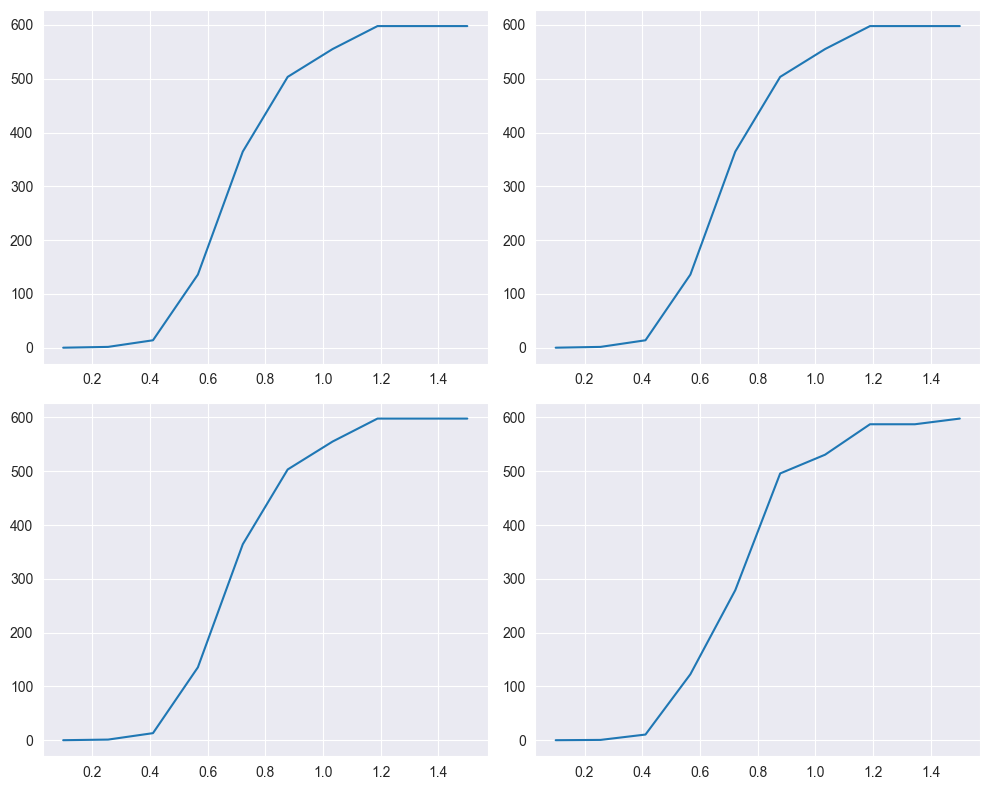

In [64]:
eps_values = np.linspace(0.1, 1.5, 10)

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.ravel()

for c, min_samples in enumerate(range(1, 5)):

    wcss = []

    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)

        m = 0.0

        for label in set(labels):
            if label == -1:
                continue

            cluster = X_scaled[labels == label]

            if len(cluster) == 0:
                continue

            center = cluster.mean(axis=0)
            m += np.sum((cluster - center) ** 2)

        wcss.append(m)

    ax[c].plot(eps_values, wcss)

plt.tight_layout()
plt.show()

In [65]:
credit_cards = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML6.1%20clustering/data/credit_card_clustering.csv', index_col=0)
credit_cards.info()

<class 'pandas.DataFrame'>
Index: 8950 entries, C10001 to C19190
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT_LIMIT   

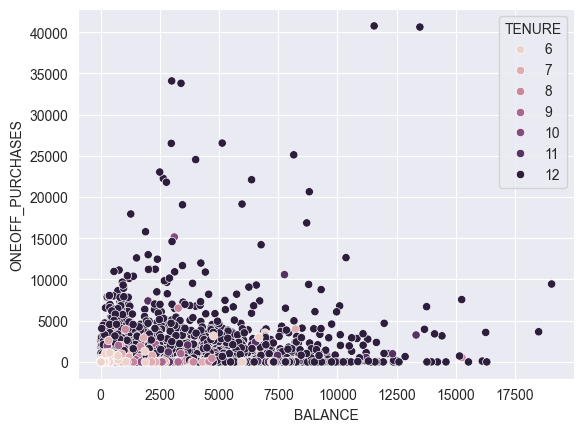

[1 0 0 ... 1 1 1]


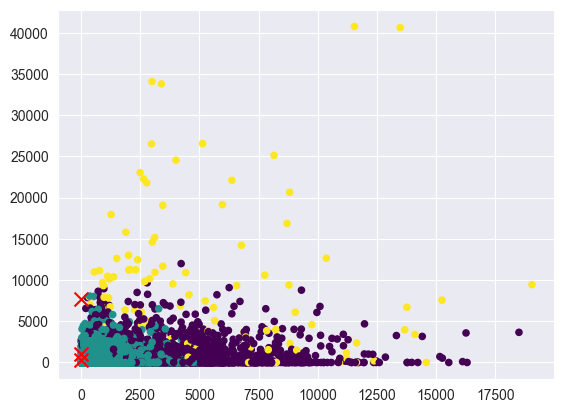

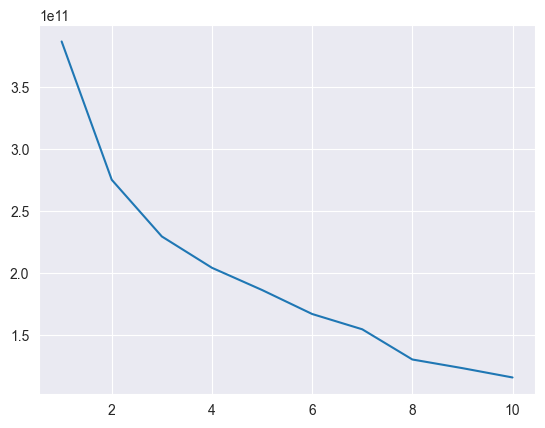

[4 0 6 ... 4 4 4]


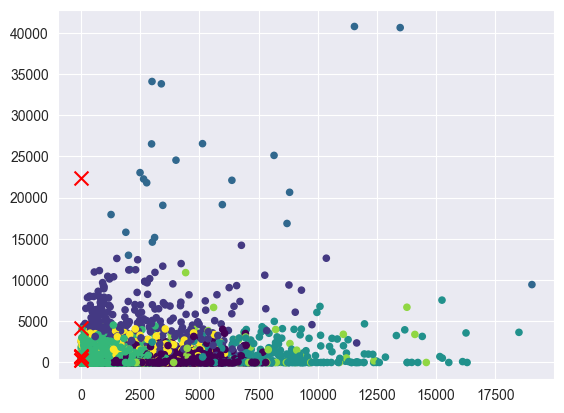

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [66]:
sns.scatterplot(x='BALANCE', y='ONEOFF_PURCHASES', hue='TENURE', data=credit_cards)
plt.show()

credit_cards = credit_cards.dropna()

k_means = KMeans(n_clusters=3, random_state=42).fit(credit_cards)
y_kmeans = k_means.labels_

print(y_kmeans)

x = credit_cards.dropna()

plt.scatter(x.BALANCE, x.ONEOFF_PURCHASES, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 3], s=100, c='red', marker='x')
plt.show()

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42).fit(credit_cards)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.show()

k_means = KMeans(n_clusters=7, random_state=42).fit(credit_cards)
y_kmeans = k_means.labels_

print(y_kmeans)

x = credit_cards.dropna()

plt.scatter(x.BALANCE, x.ONEOFF_PURCHASES, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 3], s=100, c='red', marker='x')
plt.show()

scaler = StandardScaler().fit(credit_cards)

credit_cards_scaled = scaler.transform(credit_cards)
credit_cards_scaled = pd.DataFrame(X_scaled, columns=credit_cards.columns)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42).fit(credit_cards_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.show()